# Rakamin X ID/X Partners Data Scientist Project Based Internship Program

## Task 3: Exploratory Data Analysis

### Library Import

In [535]:
from pymongo import MongoClient
from wordcloud import WordCloud
from scipy import stats
from scipy.stats import chi2_contingency
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn import linear_model
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone,BaseEstimator, TransformerMixin
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, cohen_kappa_score, classification_report
from sklearn.metrics import roc_auc_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore') 

### Data Extraction

In [536]:
client = MongoClient("mongodb://localhost:27017/")
collection = client["lendingclub_db"]["loans_clean"]
df = pd.DataFrame(list(collection.find()))

# Drop the MongoDB internal _id column
df = df.drop(columns=["_id"])
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,12000,12000,12000.0,36,13.53,407.40,B,B5,On road manager,10,...,0.0,119.17,0.0,53.0,1,INDIVIDUAL,0.0,15386.0,13605.0,8100.0
1,3000,3000,3000.0,36,12.85,100.87,B,B4,Auditor,10,...,0.0,2677.23,0.0,69.0,1,INDIVIDUAL,0.0,154.0,19530.0,5300.0
2,7200,7200,7200.0,36,10.99,235.69,B,B2,executive administrator,4,...,0.0,4539.95,0.0,59.0,1,INDIVIDUAL,0.0,0.0,45598.0,9800.0
3,9000,9000,9000.0,36,14.98,311.90,C,C3,Category Manager,10,...,0.0,5114.64,0.0,70.0,1,INDIVIDUAL,0.0,4009.0,80436.0,37200.0
4,16000,16000,16000.0,60,19.22,416.99,D,D4,District Sales Manager,8,...,0.0,416.99,0.0,60.0,1,INDIVIDUAL,0.0,0.0,188654.0,22600.0


To Analyze:
1. Target variable distribution        ← bar chart, raw labels
2. Numeric distributions               ← histograms, log scale where needed
3. Correlation matrix heatmap          ← replaces all scatterplots
4. Grade/sub-grade vs default rate     ← heatmap
5. Employment length vs loan metrics   ← box plot
6. Grade and loan status               ← stacked bar (not pie)
7. Purpose vs loan status              ← stacked bar

#### 1. Target variable value distribution

In [537]:
df['loan_status'].value_counts()

loan_status
Fully Paid            5178
Charged Off           1138
Late (31-120 days)     313
In Grace Period        137
Late (16-30 days)       70
Default                 38
Name: count, dtype: int64

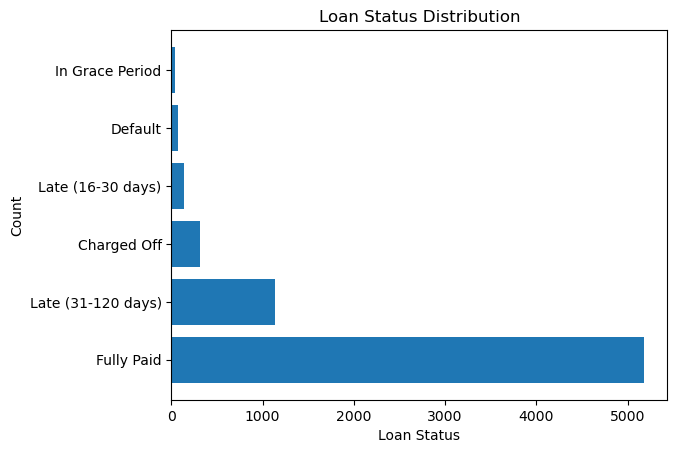

In [538]:
plt.barh(df['loan_status'].unique(), df['loan_status'].value_counts())
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

#### 2. Numerical Value Distribution

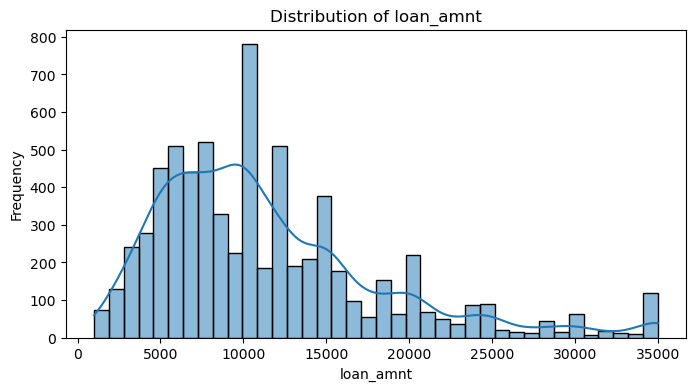

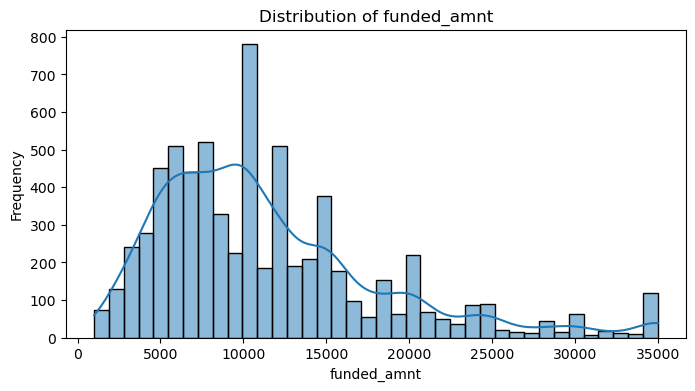

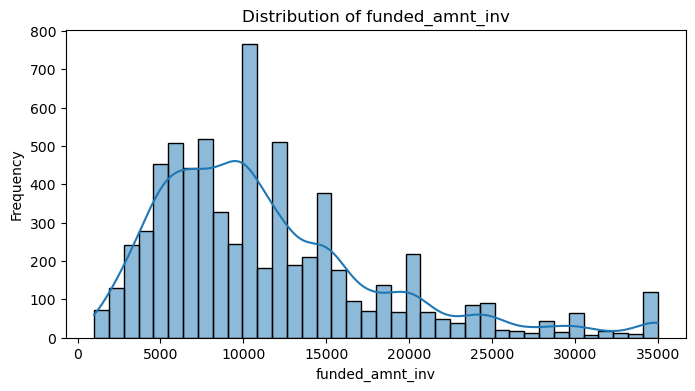

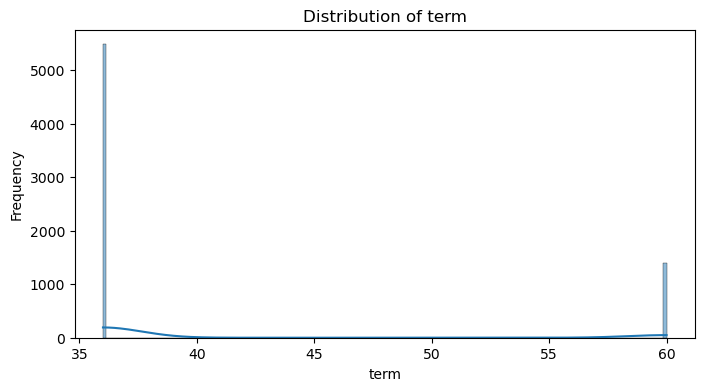

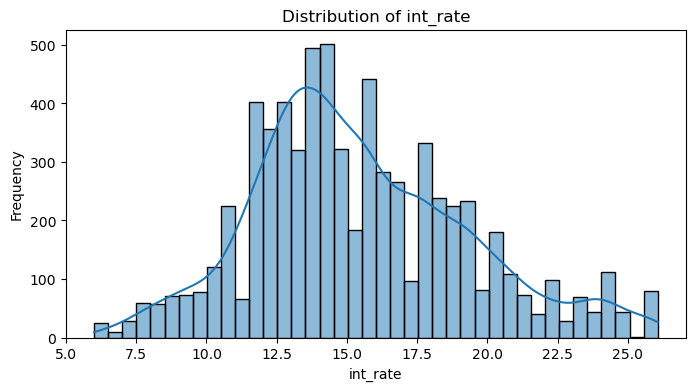

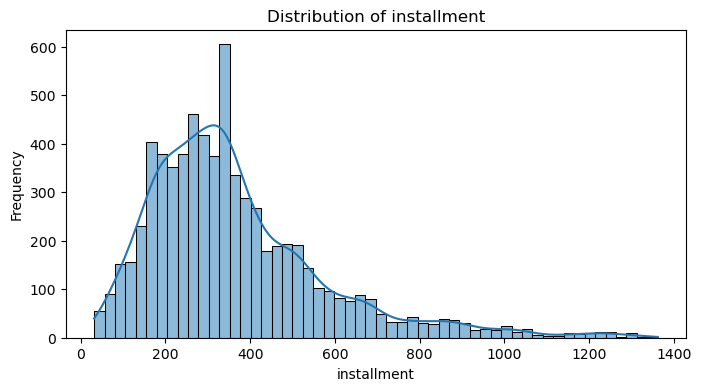

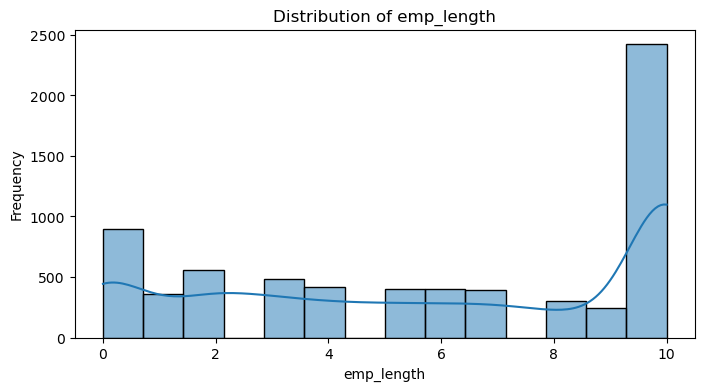

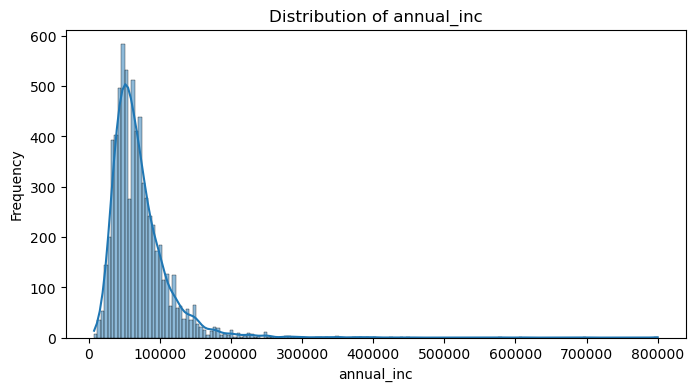

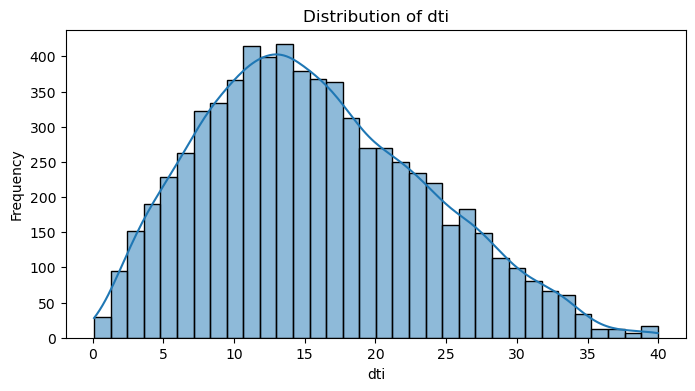

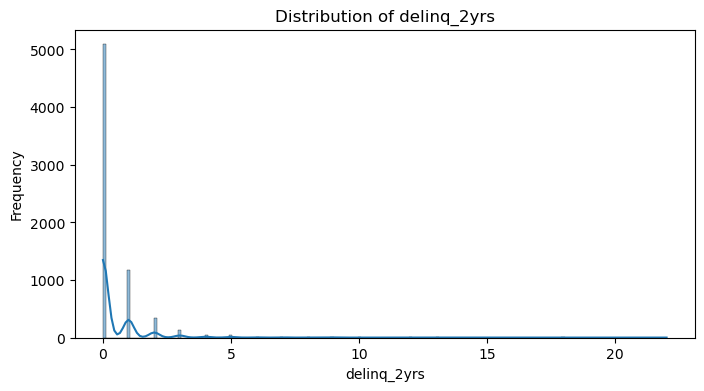

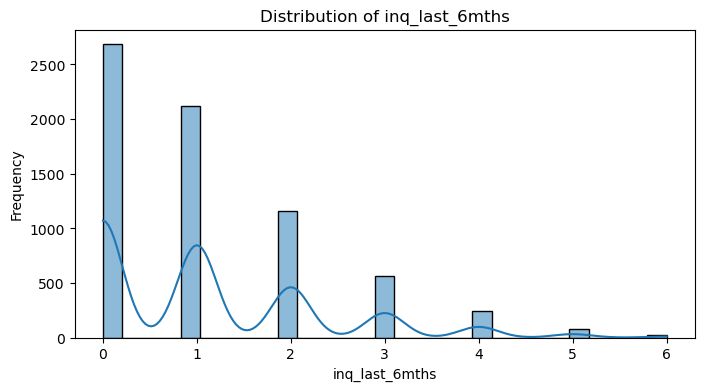

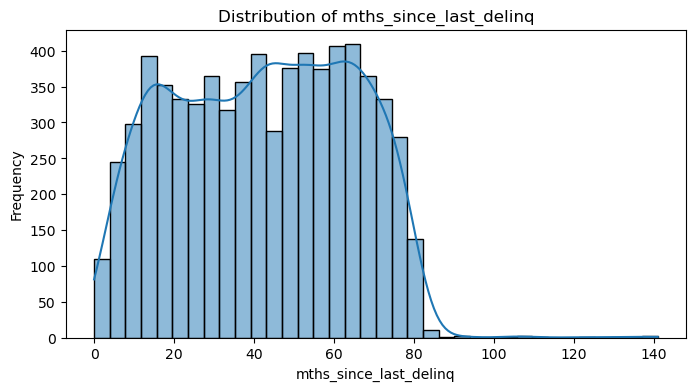

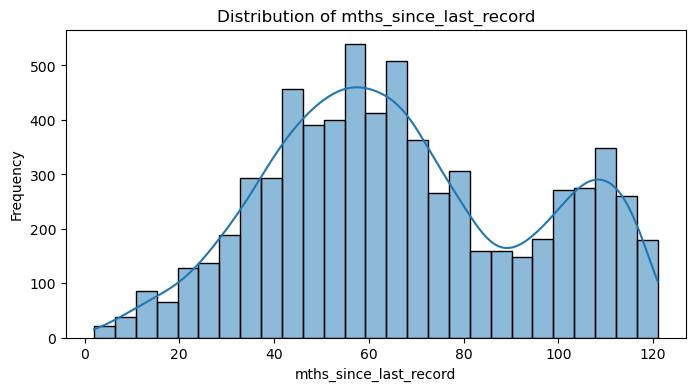

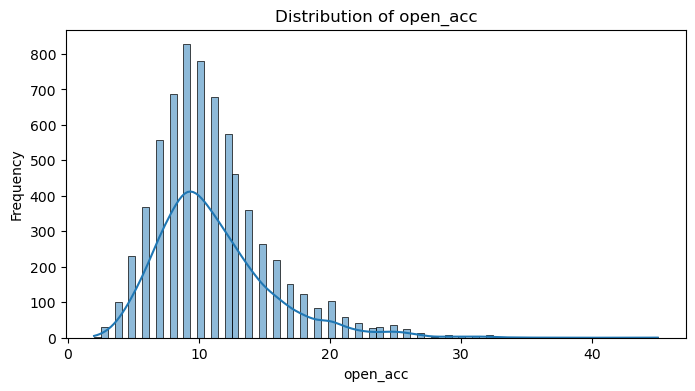

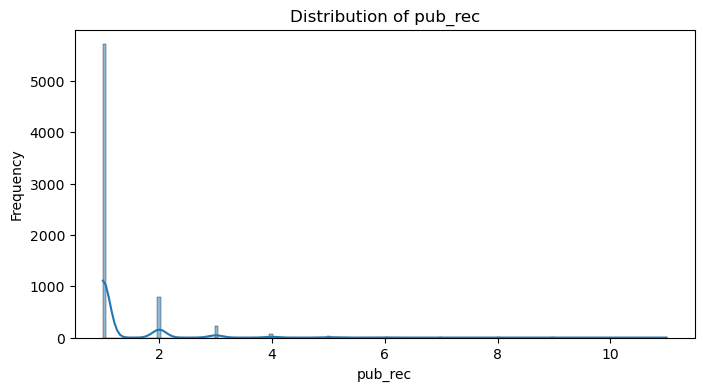

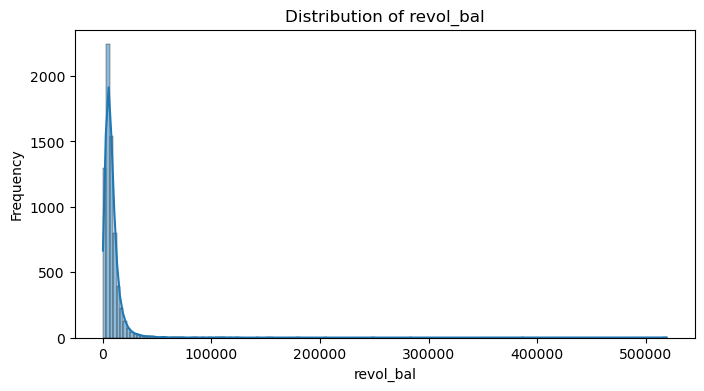

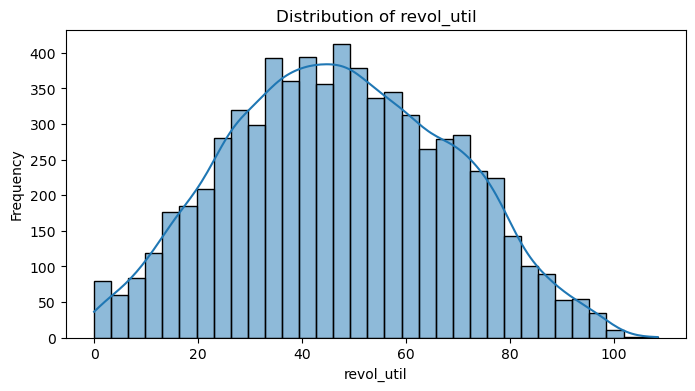

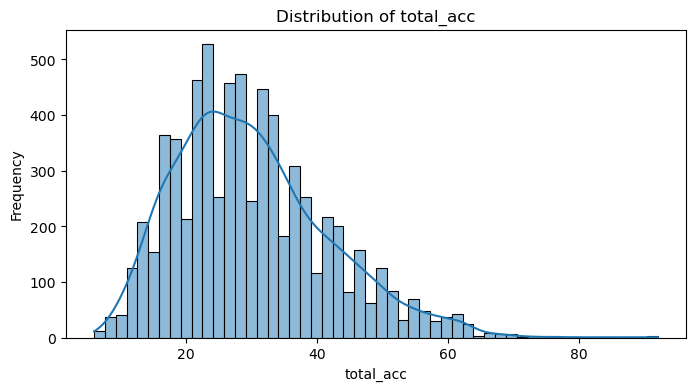

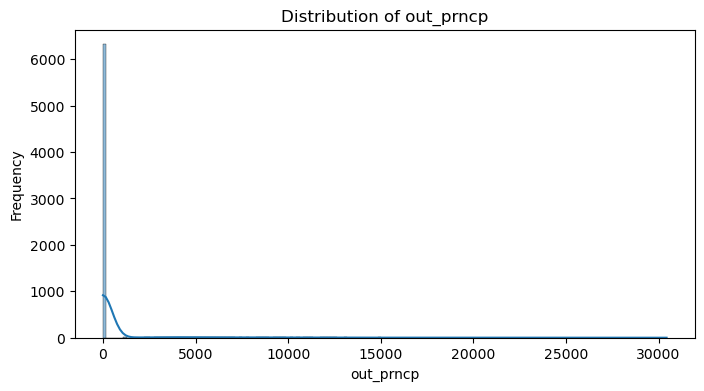

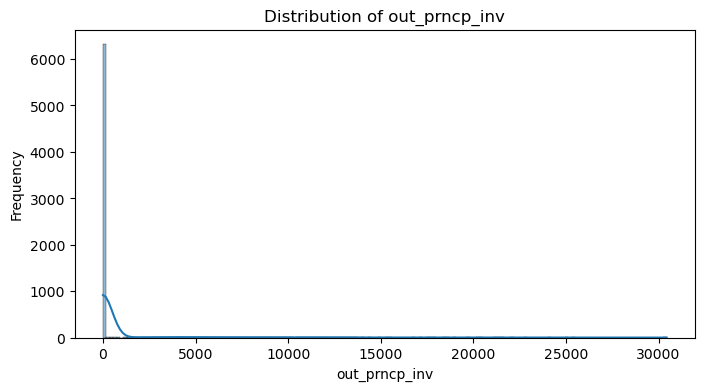

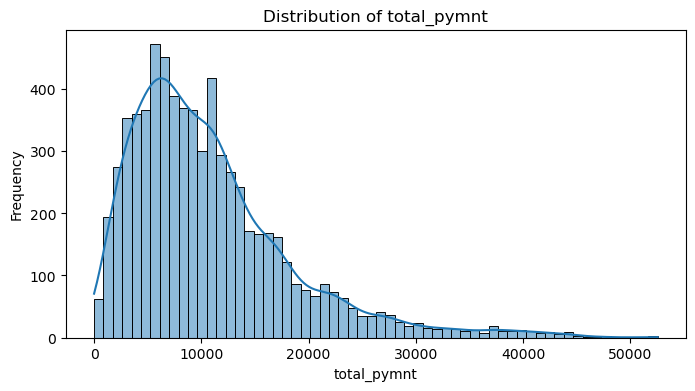

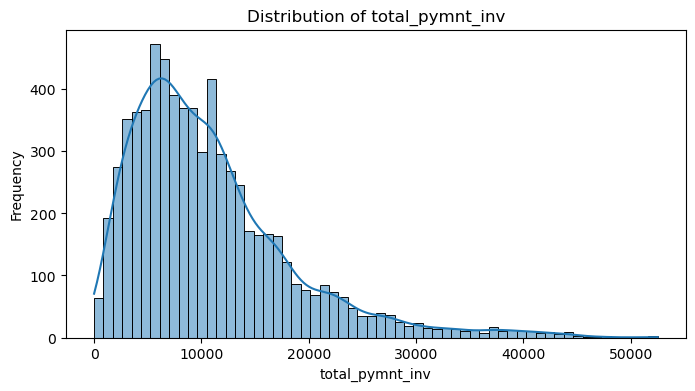

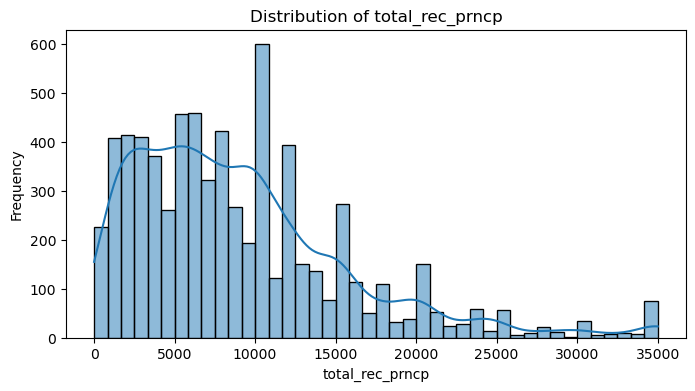

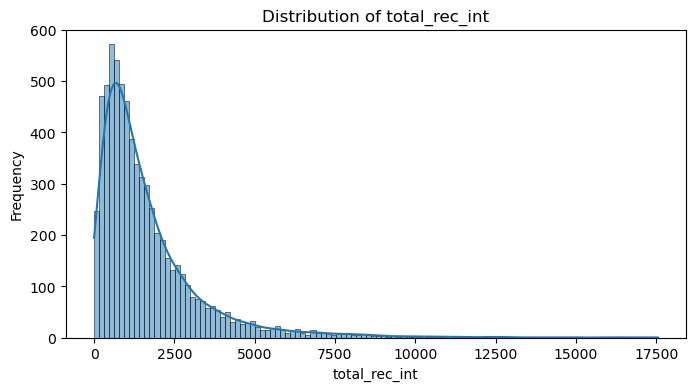

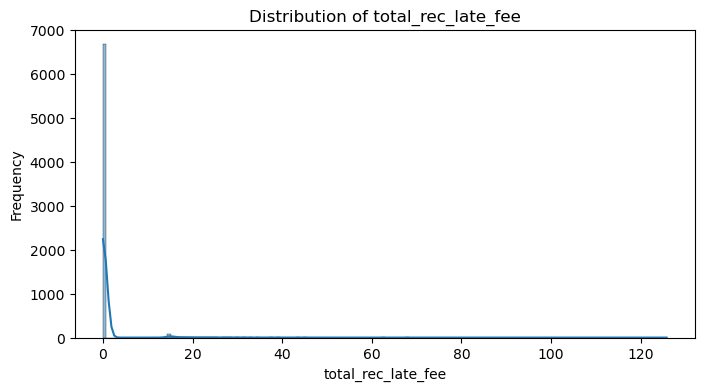

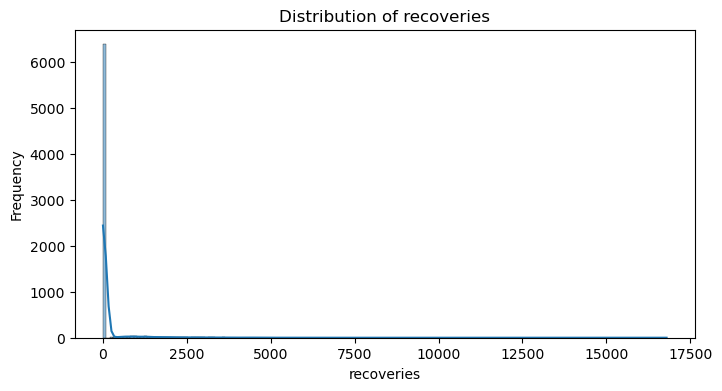

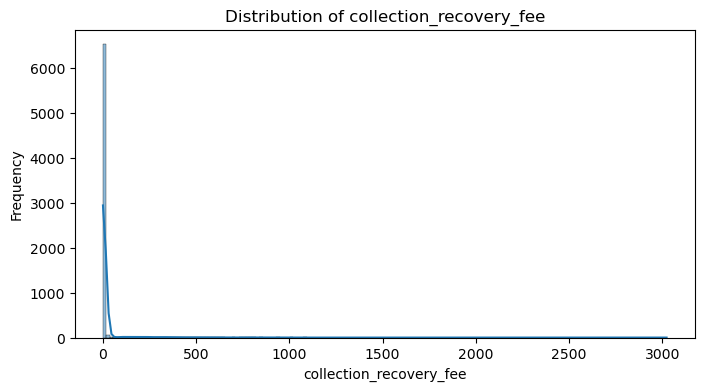

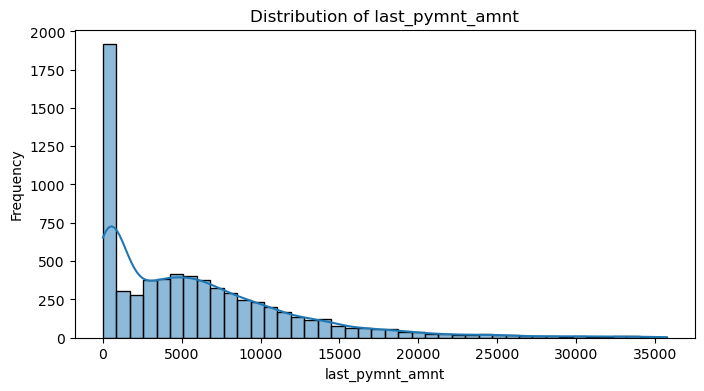

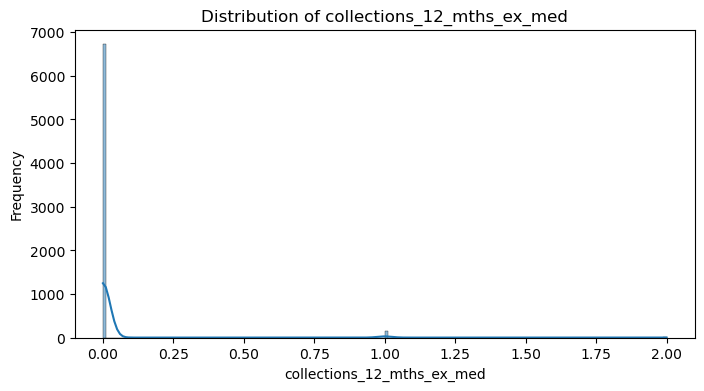

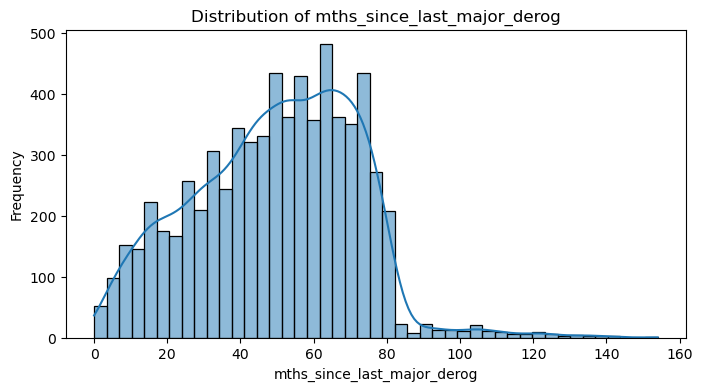

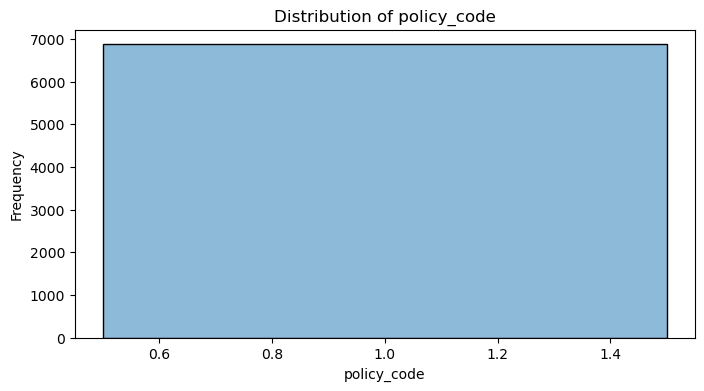

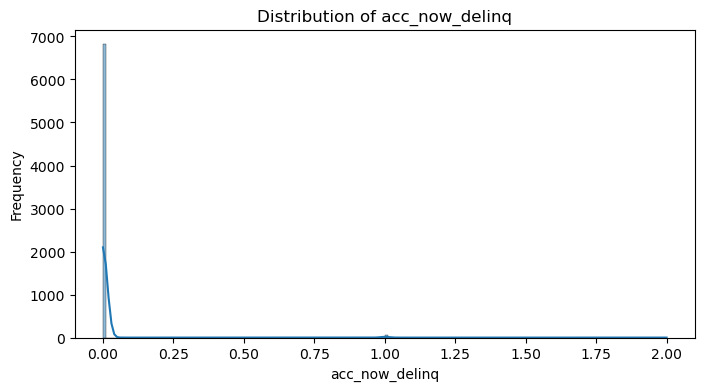

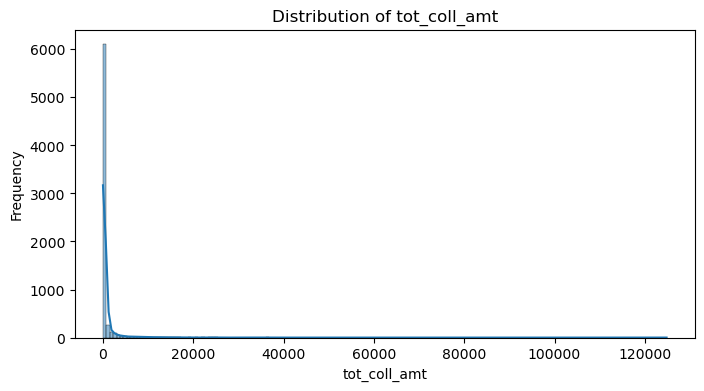

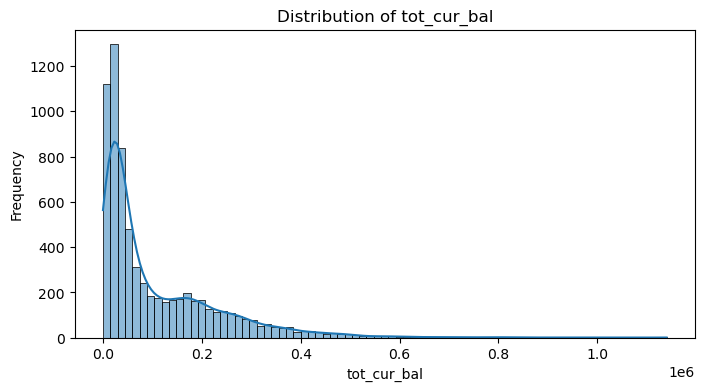

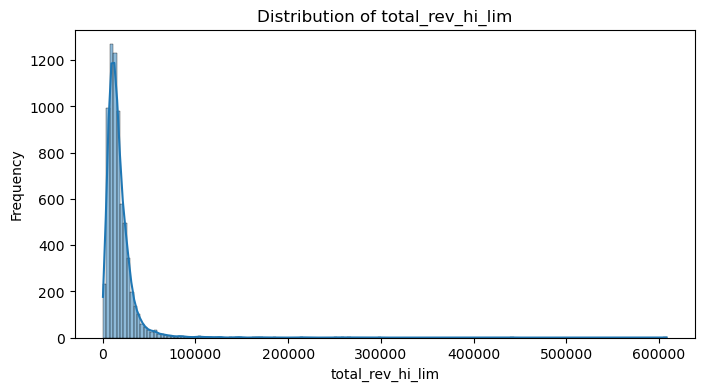

In [539]:
for col in df.columns:
    if df[col].dtype != 'object' and df[col].dtype != 'datetime64[ns]':
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()

#### 3. Numerical Value Correlation

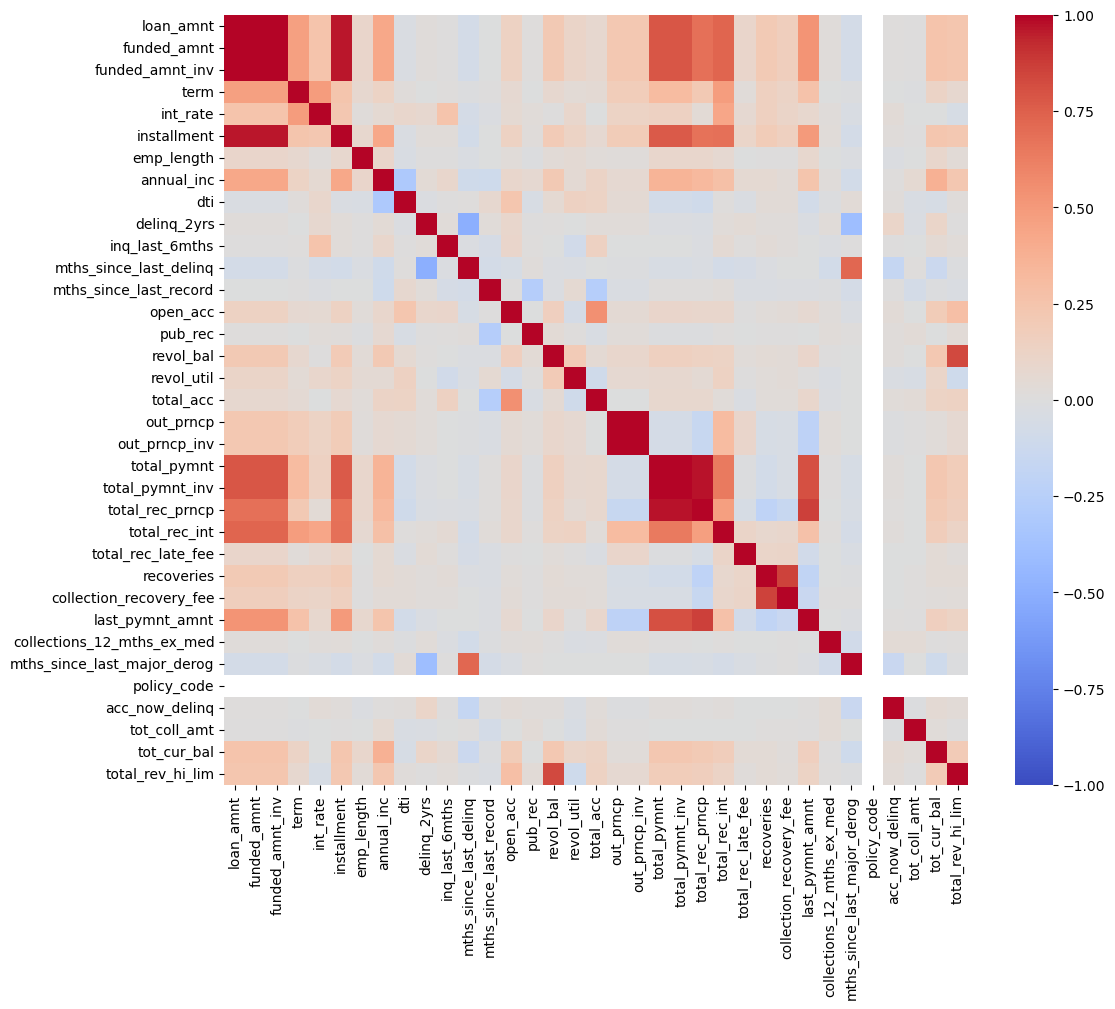

In [540]:
data = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12,10))
sns.heatmap(data, vmin=-1, vmax=1, cmap='coolwarm', annot=False, fmt='.2f')
plt.show()

#### 4. Loan Status for Each Grade

In [541]:
df['loan_status'].unique()

array(['Fully Paid', 'Late (31-120 days)', 'Charged Off',
       'Late (16-30 days)', 'Default', 'In Grace Period'], dtype=object)

In [542]:
grade_list = [i for i in df['grade'].unique()]
print(grade_list)

['B', 'C', 'D', 'A', 'F', 'E', 'G']


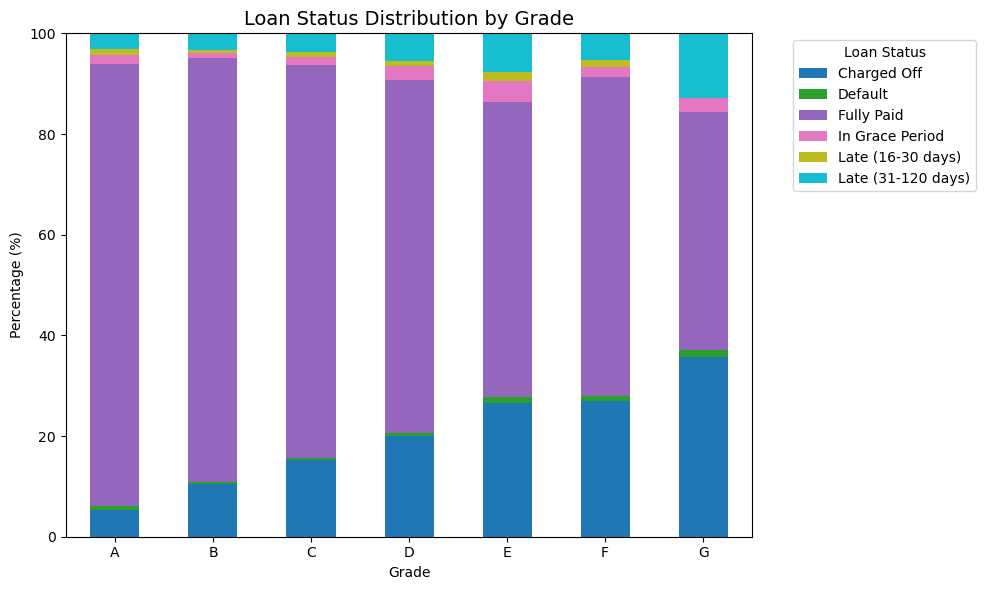

In [543]:
# Calculate percentage of each loan_status per grade
grade_status = (
    df.groupby(['grade', 'loan_status'])
    .size()
    .unstack(fill_value=0)
)

# Convert counts to percentages
grade_status_pct = grade_status.div(grade_status.sum(axis=1), axis=0) * 100

# Plot stacked bar chart
ax = grade_status_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    colormap='tab10',
    edgecolor='none'
)

# Formatting
plt.title('Loan Status Distribution by Grade', fontsize=14)
plt.xlabel('Grade')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title='Loan Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### 5. Job Titles data

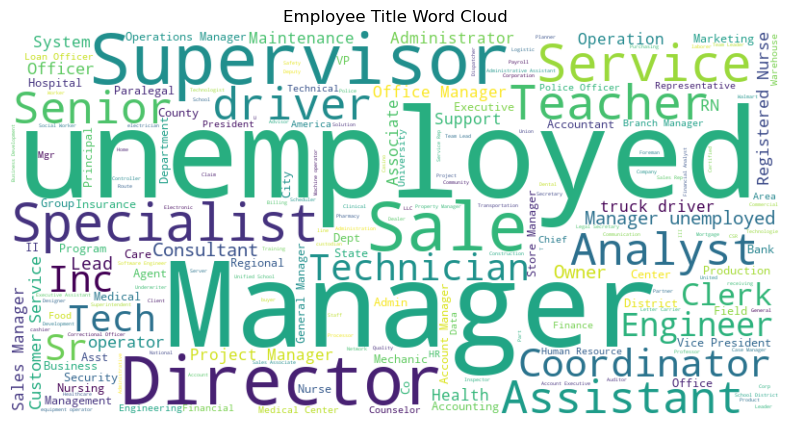

In [544]:
text = ' '.join(df['emp_title'].dropna().astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(11, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Employee Title Word Cloud')
plt.show()

#### 6. Loan Status based on employment status

In [545]:
df[df['emp_title']=='unemployed']['loan_status'].value_counts()

loan_status
Fully Paid            387
Charged Off           119
Late (31-120 days)     25
In Grace Period         6
Late (16-30 days)       4
Default                 1
Name: count, dtype: int64

In [546]:
df[df['emp_title']!='unemployed']['loan_status'].value_counts()

loan_status
Fully Paid            4791
Charged Off           1019
Late (31-120 days)     288
In Grace Period        131
Late (16-30 days)       66
Default                 37
Name: count, dtype: int64

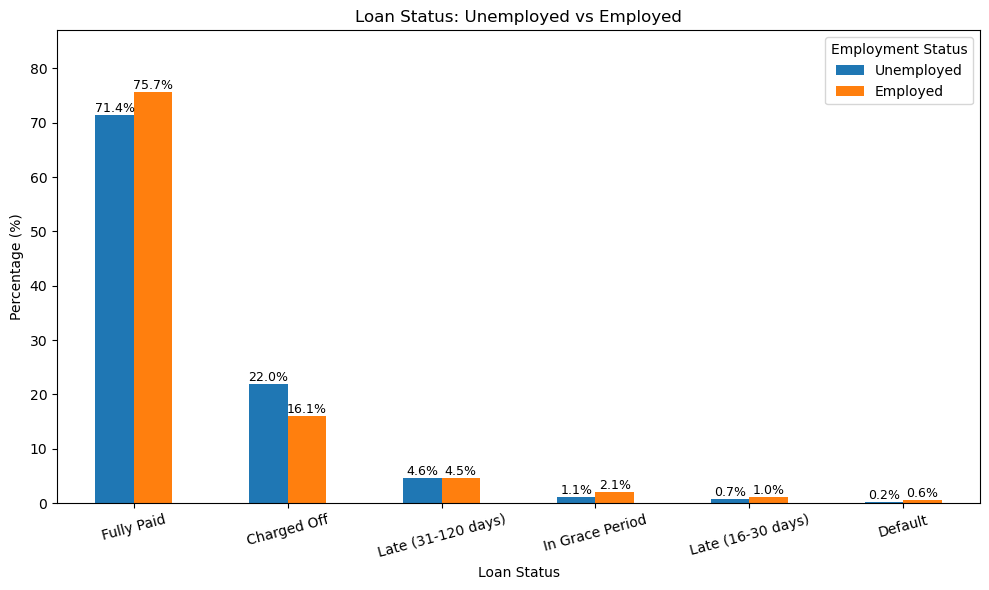

In [547]:
# Calculate percentages for each group
unemployed = (
    df[df['emp_title'] == 'unemployed']['loan_status']
    .value_counts(normalize=True) * 100
)

employed = (
    df[df['emp_title'] != 'unemployed']['loan_status']
    .value_counts(normalize=True) * 100
)

# Combine into a single DataFrame
compare_df = pd.DataFrame({
    'Unemployed': unemployed,
    'Employed': employed
}).fillna(0)

# Plot
ax = compare_df.plot(kind='bar', figsize=(10, 6), edgecolor='none')

# Add percentage labels on top of each bar
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=9
    )

plt.title('Loan Status: Unemployed vs Employed')
plt.xlabel('Loan Status')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=15)
plt.ylim(0, compare_df.values.max() * 1.15)
plt.legend(title='Employment Status')
plt.tight_layout()
plt.show()

#### 7. Employment length correlation with loan amount

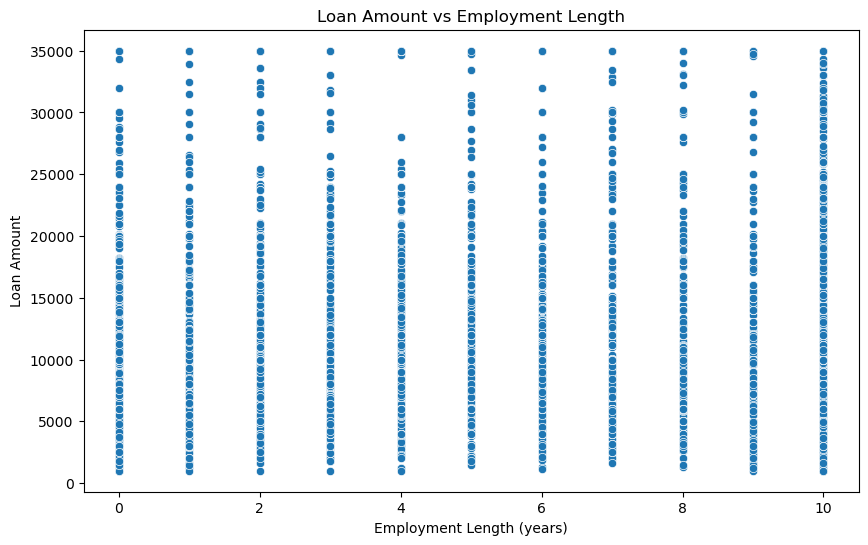

In [548]:
emp_length=df['emp_length']
borrowed=df['loan_amnt']
data = pd.DataFrame({'emp_length': emp_length, 'loan_amnt': borrowed})
plt.figure(figsize=(10, 6))
sns.scatterplot(x='emp_length', y='loan_amnt', data=data)
plt.title('Loan Amount vs Employment Length')
plt.xlabel('Employment Length (years)')
plt.ylabel('Loan Amount')
plt.show()

#### 8. Correlation between target variable with numerical columns

In [549]:
target=df['loan_status']

In [550]:
p_values = []
result = []
correlation = []

for col in df.columns:
    if df[col].dtype != 'object' and df[col].dtype != 'datetime64[ns]':
        corr, p_value = stats.pearsonr(df[col], target.astype('category').cat.codes)
        p_values.append(p_value)
        result.append('Significant' if p_value < 0.05 else 'Not Significant')
        correlation.append(corr)

pd.DataFrame({
    'Feature': df.select_dtypes(include=[np.number]).columns,
    'Correlation': correlation,
    'P-Value': p_values,
    'Significance': result
})

,Feature,Correlation,P-Value,Significance
0,loan_amnt,-0.039714,9.897976e-04,Significant
1,funded_amnt,-0.039718,9.887195e-04,Significant
2,funded_amnt_inv,-0.039739,9.825880e-04,Significant
3,term,-0.047032,9.586906e-05,Significant
4,int_rate,-0.080429,2.423291e-11,Significant
5,installment,-0.036417,2.529845e-03,Significant
6,emp_length,0.013853,2.508068e-01,Not Significant
7,annual_inc,0.008014,5.064803e-01,Not Significant
8,dti,-0.045118,1.825799e-04,Significant
9,delinq_2yrs,-0.032474,7.089151e-03,Significant


In [551]:
significant_num = []
for col in df.select_dtypes(include=[np.number]).columns:
    corr, p_value = stats.pearsonr(df[col], target.astype('category').cat.codes)
    if p_value < 0.05:
        significant_num.append(col)

#### 9. Correlation with categorical columns

In [552]:
p_values = []
result = []
correlation = []

for col in df.columns:
    if df[col].dtype == 'object':
        contingency_table = pd.crosstab(df[col], target)
        chi2, p_value, _, _ = chi2_contingency(contingency_table)
        p_values.append(p_value)
        result.append('Significant' if p_value < 0.05 else 'Not Significant')
        correlation.append(chi2)

pd.DataFrame({
    'Feature': df.select_dtypes(include=['object']).columns,
    'Chi-Squared': correlation,
    'P-Value': p_values,
    'Significance': result
})

,Feature,Chi-Squared,P-Value,Significance
0,grade,313.794553,4.999013e-49,Significant
1,sub_grade,499.489476,3.830906e-34,Significant
2,emp_title,21968.813484,9.857160e-01,Not Significant
3,home_ownership,13.579932,1.930285e-01,Not Significant
4,verification_status,41.234625,1.025435e-05,Significant
5,loan_status,34370.000000,0.000000e+00,Significant
6,pymnt_plan,0.000000,1.000000e+00,Not Significant
7,purpose,83.903475,2.251427e-02,Significant
8,title,3029.829667,1.000000e+00,Not Significant
9,zip_code,3539.847527,2.002111e-01,Not Significant


In [553]:
significant_cat = []
for col in df.select_dtypes(include=['object']).columns:
    if col != 'loan_status':
        contingency_table = pd.crosstab(df[col], target)
        chi2, p_value, _, _ = chi2_contingency(contingency_table)
        if p_value < 0.05:
            significant_cat.append(col)

In [554]:
for col in significant_cat:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

Value counts for grade:
grade
C    2226
B    1864
D    1474
E     744
F     268
A     228
G      70
Name: count, dtype: int64

Value counts for sub_grade:
sub_grade
B4    512
B5    494
C3    480
C1    459
C4    445
C2    430
B3    423
C5    412
D1    370
D2    338
D3    306
D4    257
B2    249
D5    203
E2    187
B1    186
E1    183
E3    156
E4    114
A5    105
E5    104
F2     82
A4     69
F1     65
F3     53
F4     39
F5     29
A3     28
G1     27
A2     19
G2     17
G3     14
G5      8
A1      7
G4      4
Name: count, dtype: int64

Value counts for verification_status:
verification_status
Verified           2779
Source Verified    2745
Not Verified       1350
Name: count, dtype: int64

Value counts for purpose:
purpose
debt_consolidation    4229
credit_card           1150
home_improvement       581
other                  400
major_purchase         131
small_business         101
medical                 87
car                     70
moving                  46
house                   

In [555]:
significant_cat.remove('sub_grade')

#### 10. Check if employment status is correlated or has significance

In [556]:
df['emp_status'] = df['emp_title'].apply(lambda x: 'unemployed' if x == 'unemployed' else 'employed')

In [557]:
p_values = []
result = []
correlation = []

contingency_table = pd.crosstab(df['emp_status'], target)
chi2, p_value, _, _ = chi2_contingency(contingency_table)
p_values.append(p_value)
result.append(( 'emp_status', p_value))
correlation.append(chi2)
pd.DataFrame({
    'Feature': ['emp_status'],
    'Chi-Squared': correlation,
    'P-Value': p_values,
    'Significance': ['Significant' if p_value < 0.05 else 'Not Significant']
})

,Feature,Chi-Squared,P-Value,Significance
0,emp_status,15.789486,0.007472,Significant


In [558]:
significant_cat.append('emp_status')

### Feature Engineering

In [559]:
y=df['loan_status']
X=df.drop(columns=['loan_status'])[significant_cat + significant_num]
y.replace({'Fully Paid': 0, 'In Grace Period': 1, 'Late (16-30 days)': 2, 'Late (31-120 days)': 3, 'Default': 4, 'Charged Off': 5}, inplace=True)

In [560]:
y.value_counts()

loan_status
0    5178
5    1138
3     313
1     137
2      70
4      38
Name: count, dtype: int64

In [561]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [562]:
num_cols = list(X_train.select_dtypes(include=[np.number]).columns)

listItem= []

for col in num_cols:
  listItem.append([col, round(X_train[col].skew(),1), np.where(
    (round(X_train[col].skew(),1) <= 0.5) & (round(X_train[col].skew(),1) >= -0.5),
    'normal',
    'skewed')])



skewness = pd.DataFrame(columns=['Column', 'Skewness', 'Distribution'], data= listItem)
skewness

,Column,Skewness,Distribution
0,loan_amnt,1.3,skewed
1,funded_amnt,1.3,skewed
2,funded_amnt_inv,1.3,skewed
3,term,1.5,skewed
4,int_rate,0.5,normal
5,installment,1.5,skewed
6,dti,0.4,normal
7,delinq_2yrs,6.2,skewed
8,mths_since_last_delinq,-0.0,normal
9,out_prncp,5.2,skewed


In [563]:
column = []
lower_bound = []
upper_bound = []
percent_total_outlier = []

for row in range (0, len(skewness)):
  col = skewness['Column'][row]
  #checking upper and lower boundary
  if skewness['Distribution'][row] == 'skewed':
    IQR = X_train[col].quantile(0.75) - X_train[col].quantile(0.25)
    lower_boundary = X_train[col].quantile(0.25) - (IQR * 3)
    upper_boundary = X_train[col].quantile(0.75) + (IQR * 3)
  else:
    lower_boundary = X_train[col].mean() - 3* X_train[col].std()
    upper_boundary = X_train[col].mean() + 3* X_train[col].std()
  #append to list
  column.append(col)
  lower_bound.append(lower_boundary)
  upper_bound.append(upper_boundary)
  totout = ((len(X_train[X_train[col] > upper_boundary]) / len(X_train) * 100) + (len(X_train[X_train[col] < lower_boundary]) / len(X_train) * 100))
  percent_total_outlier.append(totout)

outliers = pd.DataFrame({
    'column': column,
    #round the value
    'upper_boundary': [round(upper_bound,2) for upper_bound in upper_bound],
    'lower_boundary': [round(lower_bound,2) for lower_bound in lower_bound],
    'percentage_total_outlier': [round(percent_total_outlier,2) for percent_total_outlier in percent_total_outlier]
})
outliers

,column,upper_boundary,lower_boundary,percentage_total_outlier
0,loan_amnt,40500.00,-19000.00,0.00
1,funded_amnt,40500.00,-19000.00,0.00
2,funded_amnt_inv,40500.00,-19000.00,0.00
3,term,36.00,36.00,20.41
4,int_rate,26.95,3.95,0.00
5,installment,1158.79,-483.62,0.89
6,dti,39.11,-7.75,0.16
7,delinq_2yrs,4.00,-3.00,1.49
8,mths_since_last_delinq,108.23,-24.10,0.08
9,out_prncp,0.00,0.00,8.15


In [564]:
num_features_scaler= []
num_features_minmax = []
for col in outliers['column']:
  if -1<=outliers[outliers['column'] == col]['percentage_total_outlier'].values[0] <=1 :
    num_features_scaler.append(col)
  else:
    num_features_minmax.append(col)

In [565]:
for col in X.columns:
    if X[col].dtype == 'object':
        print(f"Column: {col}")
        print(X[col].value_counts())
        print("\n")

Column: grade
grade
C    2226
B    1864
D    1474
E     744
F     268
A     228
G      70
Name: count, dtype: int64


Column: verification_status
verification_status
Verified           2779
Source Verified    2745
Not Verified       1350
Name: count, dtype: int64


Column: purpose
purpose
debt_consolidation    4229
credit_card           1150
home_improvement       581
other                  400
major_purchase         131
small_business         101
medical                 87
car                     70
moving                  46
house                   38
vacation                32
wedding                  6
renewable_energy         3
Name: count, dtype: int64


Column: emp_status
emp_status
employed      6332
unemployed     542
Name: count, dtype: int64




In [566]:
print(significant_cat)

['grade', 'verification_status', 'purpose', 'emp_status']


In [567]:
ordinal_features = ['grade','verification_status']
onehot_features = ['purpose','emp_status']

In [568]:
grade_ordinal = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
grade_ord = OrdinalEncoder(categories=[grade_ordinal], dtype=int)
verification_status_ordinal = ['Not Verified', 'Source Verified', 'Verified']
verification_status_ord = OrdinalEncoder(categories=[verification_status_ordinal], dtype=int)

In [569]:
numerical_transformer_scaler = Pipeline(steps=[
    ('scaler', StandardScaler())
])
numerical_transformer_minmax = Pipeline(steps=[
    ('minmax', MinMaxScaler())
])
categorical_transformer_onehot = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])
categorical_transformer_ordinal = Pipeline(steps=[
    ('ordinal', OrdinalEncoder())
])

In [570]:
preprocessor = ColumnTransformer(transformers=[
    ('num_scaler', numerical_transformer_scaler, num_features_scaler),
    ('num_minmax', numerical_transformer_minmax, num_features_minmax),
    ('cat_onehot', categorical_transformer_onehot, onehot_features),
    # Each ordinal feature gets its own encoder with the correct category order
    ('cat_grade', Pipeline(steps=[('ordinal', grade_ord)]), ['grade']),
    ('cat_verification', Pipeline(steps=[('ordinal', verification_status_ord)]), ['verification_status']),
])

smote = SMOTE(sampling_strategy='not majority', k_neighbors=5, random_state=42)


In [571]:
class DataFrameConverter(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.n_features_in_ = X.shape[1]  
        return self

    def transform(self, X, y=None):
        return pd.DataFrame(X) 

In [572]:
pipe_logreg = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', smote),
    ('df_converter', DataFrameConverter()),  # ✅ no external reference
    ('classifier', linear_model.LogisticRegression(random_state=42))
])

pipe_rf = ImbPipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('smote', smote),
    ('df_converter', DataFrameConverter()),  # ✅ no external reference
    ('classifier', RandomForestClassifier(random_state=42))
])

pipe_dt = ImbPipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('smote', smote),
    ('df_converter', DataFrameConverter()),  # ✅ no external reference
    ('classifier', DecisionTreeClassifier(random_state=42))
])

pipe_xgb = ImbPipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('smote', smote),
    ('df_converter', DataFrameConverter()),  # ✅ no external reference
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'))
])

pipe_svc = ImbPipeline(steps=[
    ('preprocessor', clone(preprocessor)),
    ('smote', smote),
    ('df_converter', DataFrameConverter()),  # ✅ no external reference
    ('classifier', SVC(random_state=42, probability=True))
])

In [573]:
pipe_logreg.fit(X_train, y_train)
y_pred_logreg = pipe_logreg.predict(X_test)

In [574]:
print(classification_report(y_test, y_pred_logreg))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1292
           1       0.18      0.25      0.21        28
           2       0.20      0.25      0.22        24
           3       0.56      0.26      0.36        76
           4       0.15      0.60      0.24        10
           5       0.99      0.99      0.99       289

    accuracy                           0.93      1719
   macro avg       0.51      0.56      0.50      1719
weighted avg       0.95      0.93      0.94      1719



In [575]:
# Penalizes predictions that are far off in order
mae = mean_absolute_error(y_test, y_pred_logreg)

# Kappa with linear/quadratic weighting — great for ordinal
kappa = cohen_kappa_score(y_test, y_pred_logreg, weights='quadratic')

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Cohen's Kappa (quadratic): {kappa:.4f}")

Mean Absolute Error: 0.1053
Cohen's Kappa (quadratic): 0.9702


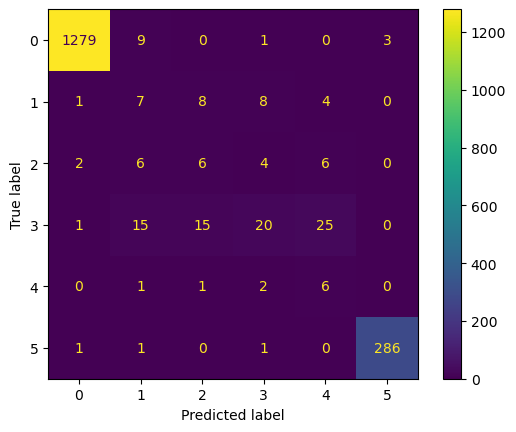

In [576]:
cm_test= confusion_matrix(y_test, y_pred_logreg)
ConfusionMatrixDisplay(cm_test).plot()

In [577]:
eval_logreg = {
    'Metric': ['False Negatives','Mean Absolute Error', "Cohen's Kappa (quadratic)"],
    'Score': [
        cm_test[1][0],  # False Negatives
        mae,
        kappa
    ]
}

In [578]:
pipe_rf.fit(X_train, y_train)
y_pred_randfor= pipe_rf.predict(X_test)

In [579]:
print(classification_report(y_test, y_pred_randfor))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1292
           1       0.17      0.18      0.18        28
           2       0.18      0.08      0.11        24
           3       0.52      0.64      0.58        76
           4       0.00      0.00      0.00        10
           5       1.00      0.99      1.00       289

    accuracy                           0.95      1719
   macro avg       0.48      0.48      0.48      1719
weighted avg       0.95      0.95      0.95      1719



In [580]:
# Penalizes predictions that are far off in order
mae = mean_absolute_error(y_test, y_pred_randfor)

# Kappa with linear/quadratic weighting — great for ordinal
kappa = cohen_kappa_score(y_test, y_pred_randfor, weights='quadratic')

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Cohen's Kappa (quadratic): {kappa:.4f}")

Mean Absolute Error: 0.0750
Cohen's Kappa (quadratic): 0.9808


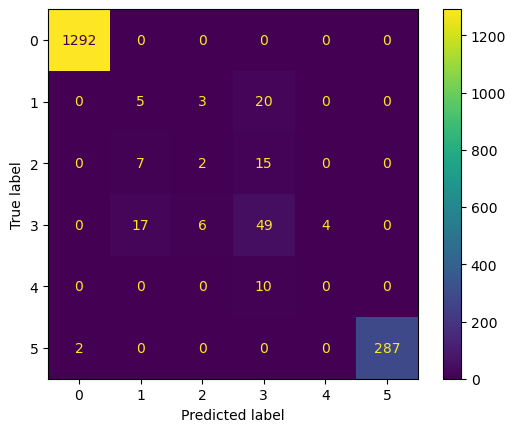

In [581]:
cm_test_rf= confusion_matrix(y_test, y_pred_randfor)
ConfusionMatrixDisplay(cm_test_rf).plot()

In [582]:
eval_randfor = {
    'Metric': ['False Negatives','Mean Absolute Error', "Cohen's Kappa (quadratic)"],
    'Score': [cm_test_rf[1, 0], mae, kappa]
}

In [583]:
pipe_dt.fit(X_train, y_train)
y_pred_dt= pipe_dt.predict(X_test)

In [584]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1292
           1       0.21      0.29      0.24        28
           2       0.16      0.12      0.14        24
           3       0.49      0.42      0.45        76
           4       0.00      0.00      0.00        10
           5       0.99      0.99      0.99       289

    accuracy                           0.94      1719
   macro avg       0.48      0.47      0.47      1719
weighted avg       0.94      0.94      0.94      1719



In [585]:
mae = mean_absolute_error(y_test, y_pred_dt)
kappa = cohen_kappa_score(y_test, y_pred_dt, weights='quadratic')
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Cohen's Kappa (quadratic): {kappa:.4f}")

Mean Absolute Error: 0.0937
Cohen's Kappa (quadratic): 0.9729


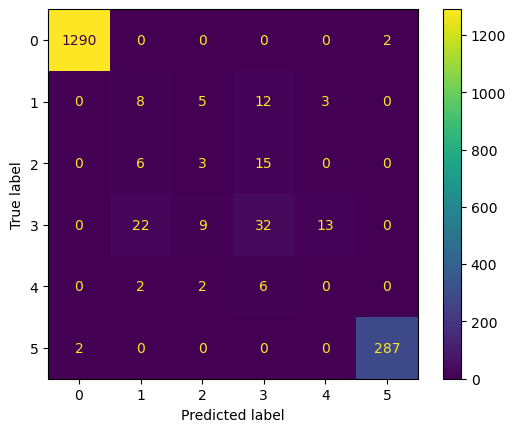

In [586]:
cm_test_dt= confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_test_dt).plot()

In [587]:
eval_dt = {
    'Metric': ['False Negatives','Mean Absolute Error', "Cohen's Kappa (quadratic)"],
    'Score': [cm_test_dt[1, 0], mae, kappa]
}

In [588]:
pipe_xgb.fit(X_train, y_train)
y_pred_xgb= pipe_xgb.predict(X_test)

In [589]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1292
           1       0.27      0.32      0.30        28
           2       0.25      0.08      0.12        24
           3       0.52      0.59      0.55        76
           4       0.00      0.00      0.00        10
           5       1.00      0.99      1.00       289

    accuracy                           0.95      1719
   macro avg       0.51      0.50      0.49      1719
weighted avg       0.95      0.95      0.95      1719



In [590]:
mae = mean_absolute_error(y_test, y_pred_xgb)
kappa = cohen_kappa_score(y_test, y_pred_xgb, weights='quadratic')
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Cohen's Kappa (quadratic): {kappa:.4f}")

Mean Absolute Error: 0.0768
Cohen's Kappa (quadratic): 0.9797


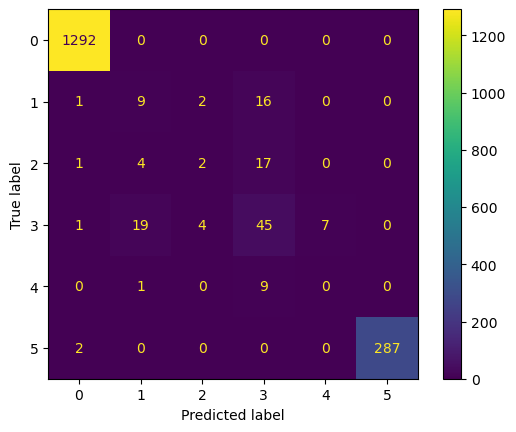

In [591]:
cm_test_xgb= confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_test_xgb).plot()

In [592]:
eval_xgb = {
    'Metric': ['False Negatives','Mean Absolute Error', "Cohen's Kappa (quadratic)"],
    'Score': [cm_test_xgb[1, 0], mae, kappa]
}

In [593]:
pipe_svc.fit(X_train, y_train)
y_pred_svc= pipe_svc.predict(X_test)

In [594]:
print(classification_report(y_test, y_pred_svc))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1292
           1       0.19      0.32      0.24        28
           2       0.19      0.21      0.20        24
           3       0.53      0.41      0.46        76
           4       0.00      0.00      0.00        10
           5       0.98      0.96      0.97       289

    accuracy                           0.93      1719
   macro avg       0.48      0.48      0.48      1719
weighted avg       0.94      0.93      0.94      1719



In [595]:
mae = mean_absolute_error(y_test, y_pred_svc)
kappa = cohen_kappa_score(y_test, y_pred_svc, weights='quadratic')
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Cohen's Kappa (quadratic): {kappa:.4f}")

Mean Absolute Error: 0.1227
Cohen's Kappa (quadratic): 0.9560


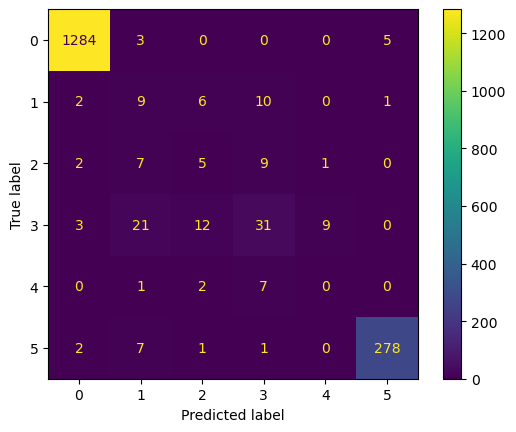

In [596]:
cm_test_svc= confusion_matrix(y_test, y_pred_svc)
ConfusionMatrixDisplay(cm_test_svc).plot()

In [597]:
eval_svc = {
    'Metric': ['False Negatives','Mean Absolute Error', "Cohen's Kappa (quadratic)"],
    'Score': [cm_test_svc[1, 0], mae, kappa]
}

In [598]:
evaluation=pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Decision Tree', 'XGBoost', 'SVC'],
    'False Negatives': [eval_logreg['Score'][0], eval_randfor['Score'][0], eval_dt['Score'][0], eval_xgb['Score'][0], eval_svc['Score'][0]],
    'Mean Absolute Error': [eval_logreg['Score'][1], eval_randfor['Score'][1], eval_dt['Score'][1], eval_xgb['Score'][1], eval_svc['Score'][1]],
    "Cohen's Kappa (quadratic)": [eval_logreg['Score'][2], eval_randfor['Score'][2], eval_dt['Score'][2], eval_xgb['Score'][2], eval_svc['Score'][2]]
})

evaluation.set_index('Model', inplace=True)

In [599]:
evaluation

,False Negatives,Mean Absolute Error,Cohen's Kappa (quadratic)
Model,,,
Logistic Regression,1,0.105294,0.970181
Random Forest,0,0.075044,0.980772
Decision Tree,0,0.093659,0.972924
XGBoost,1,0.076789,0.979743
SVC,2,0.122746,0.955983


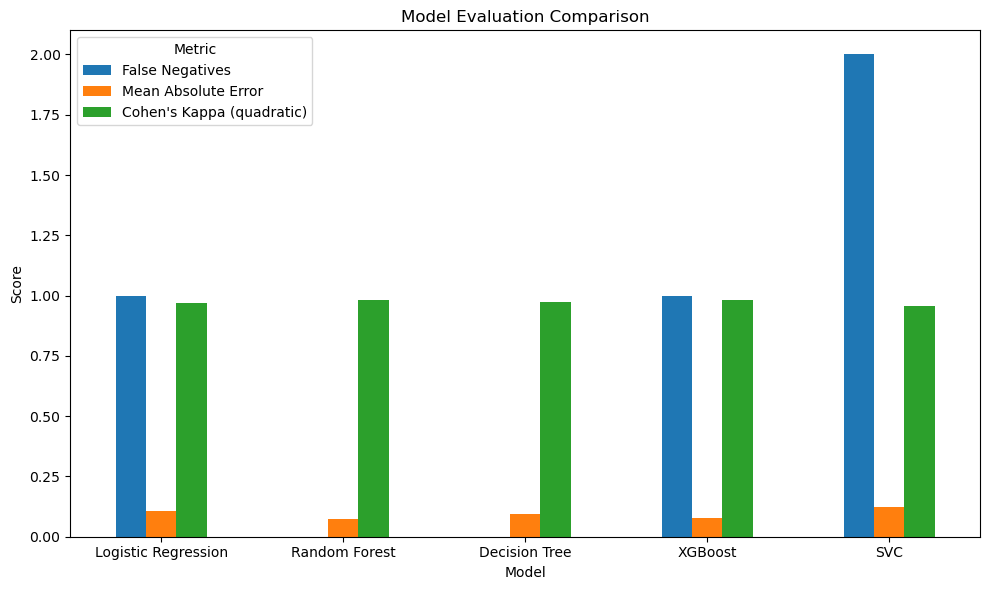

In [600]:
evaluation.plot(kind='bar', figsize=(10, 6), edgecolor='none')
plt.title('Model Evaluation Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [601]:
pipe_rf.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'smote', 'df_converter', 'classifier', 'preprocessor__force_int_remainder_cols', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num_scaler', 'preprocessor__num_minmax', 'preprocessor__cat_onehot', 'preprocessor__cat_grade', 'preprocessor__cat_verification', 'preprocessor__num_scaler__memory', 'preprocessor__num_scaler__steps', 'preprocessor__num_scaler__transform_input', 'preprocessor__num_scaler__verbose', 'preprocessor__num_scaler__scaler', 'preprocessor__num_scaler__scaler__copy', 'preprocessor__num_scaler__scaler__with_mean', 'preprocessor__num_scaler__scaler__with_std', 'preprocessor__num_minmax__memory', 'preprocessor__num_minmax__steps', 'preprocessor__num_minmax__transform_input', 'preprocessor__num_minmax__verbose', '

In [602]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10]
}

grid_search = GridSearchCV(pipe_rf, param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best parameters found:  {'classifier__max_depth': None, 'classifier__n_estimators': 200}


In [603]:
y_pred_randfor_tuned = grid_search.predict(X_test)

In [604]:
print(classification_report(y_test, y_pred_randfor_tuned))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1292
           1       0.17      0.18      0.18        28
           2       0.22      0.08      0.12        24
           3       0.53      0.67      0.59        76
           4       0.00      0.00      0.00        10
           5       1.00      0.99      1.00       289

    accuracy                           0.95      1719
   macro avg       0.49      0.49      0.48      1719
weighted avg       0.95      0.95      0.95      1719



In [605]:
# Penalizes predictions that are far off in order
mae = mean_absolute_error(y_test, y_pred_randfor_tuned)

# Kappa with linear/quadratic weighting — great for ordinal
kappa = cohen_kappa_score(y_test, y_pred_randfor_tuned, weights='quadratic')

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Cohen's Kappa (quadratic): {kappa:.4f}")

Mean Absolute Error: 0.0739
Cohen's Kappa (quadratic): 0.9809


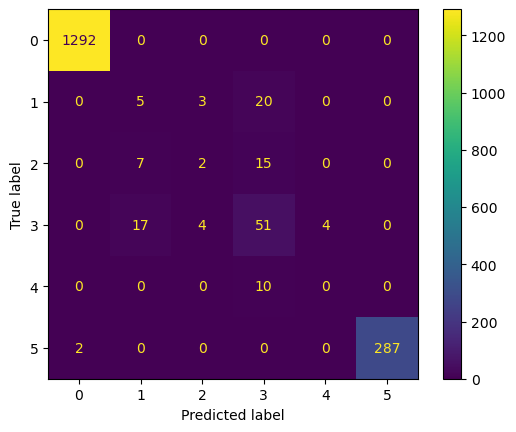

In [606]:
cm_test_tuned= confusion_matrix(y_test, y_pred_randfor_tuned)
ConfusionMatrixDisplay(cm_test_tuned).plot()

In [607]:
eval_tuned_rf = {
    'Metric': ['False Negatives','Mean Absolute Error', "Cohen's Kappa (quadratic)"],
    'Score': [cm_test_tuned[1, 0], mae, kappa]
}

In [609]:
evaluation=pd.concat([evaluation, pd.DataFrame({
    'Model': ['Tuned Random Forest'],
    'False Negatives': [eval_tuned_rf['Score'][0]],
    'Mean Absolute Error': [eval_tuned_rf['Score'][1]],
    "Cohen's Kappa (quadratic)": [eval_tuned_rf['Score'][2]]
}).set_index('Model')])

Text(0.5, 1.0, 'Model Evaluation Comparison')

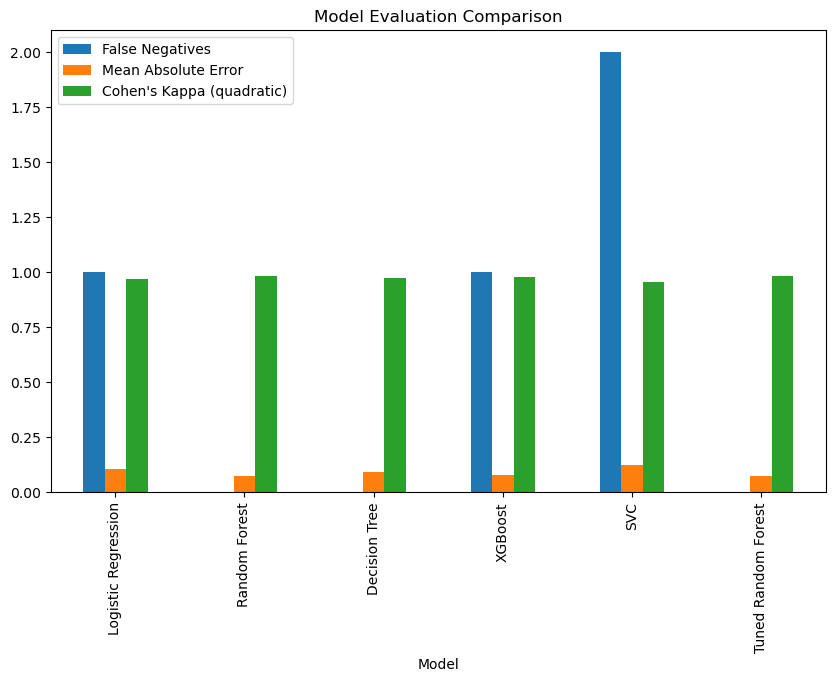

In [610]:
evaluation.plot(kind='bar', figsize=(10, 6), edgecolor='none')
plt.title('Model Evaluation Comparison')

In [611]:
evaluation

,False Negatives,Mean Absolute Error,Cohen's Kappa (quadratic)
Model,,,
Logistic Regression,1,0.105294,0.970181
Random Forest,0,0.075044,0.980772
Decision Tree,0,0.093659,0.972924
XGBoost,1,0.076789,0.979743
SVC,2,0.122746,0.955983
Tuned Random Forest,0,0.073880,0.980939


In [612]:
model_best = grid_search.best_estimator_
joblib.dump(model_best, open('model_best.pkl', 'wb'))

In [613]:
model_best

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_scaler', ...), ('num_minmax', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready 